In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_curve, auc, accuracy_score

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, 
                           n_classes=2, random_state=42)

In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training data shape: {X_train.shape}")
print(f"Testing data shape: {X_test.shape}\n")

Training data shape: (700, 10)
Testing data shape: (300, 10)



In [5]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

In [6]:
results = {}

for name, model in models.items():
    # 1. Train the model
    model.fit(X_train, y_train)
    
    # 2. Make predictions on the test set
    y_pred = model.predict(X_test)
    
    # 3. Get probabilities (needed for the ROC curve)
    y_prob = model.predict_proba(X_test)[:, 1]

In [7]:
results[name] = {'predictions': y_pred, 'probabilities': y_prob}

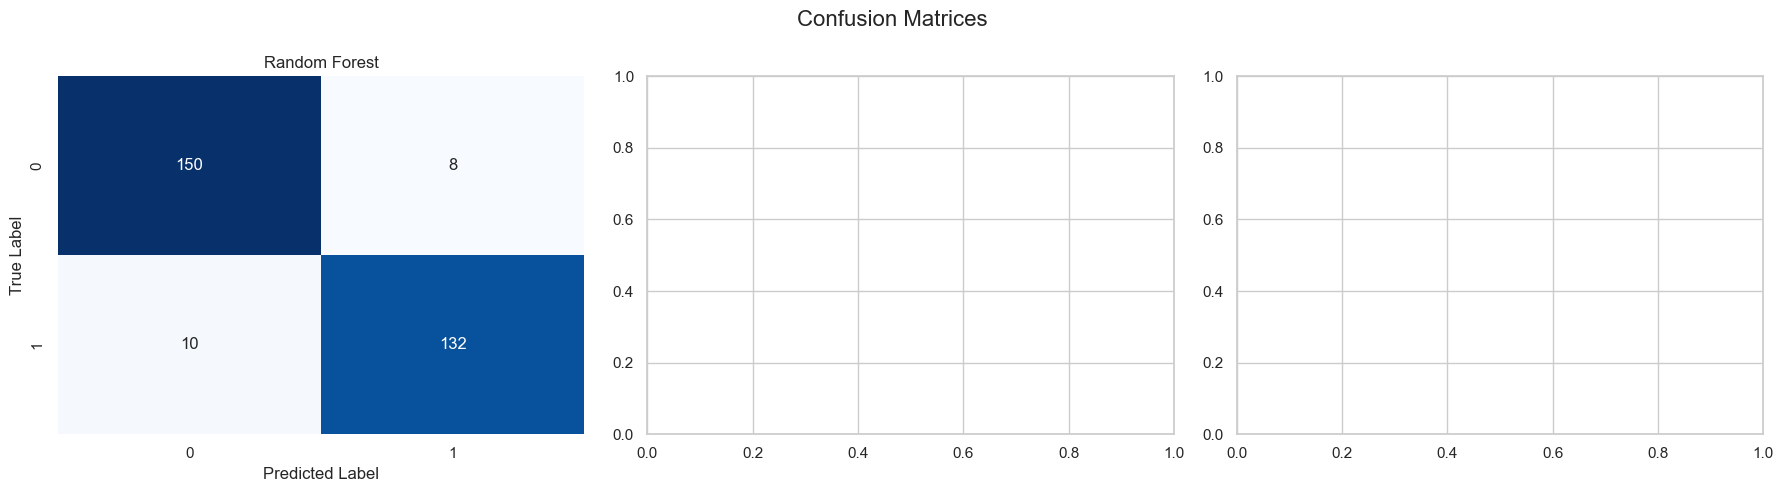

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices', fontsize=16)

for i, (name, data) in enumerate(results.items()):
    cm = confusion_matrix(y_test, data['predictions'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name)
    axes[i].set_xlabel('Predicted Label')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

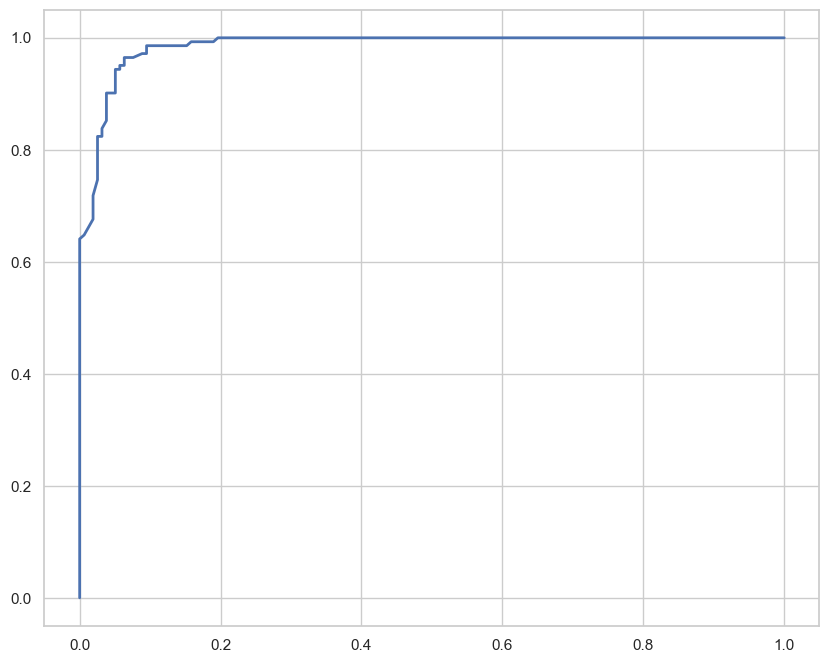

In [10]:
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

for name, data in results.items():
    # Calculate False Positive Rate and True Positive Rate
    fpr, tpr, _ = roc_curve(y_test, data['probabilities'])
    
    # Calculate Area Under the Curve (AUC)
    roc_auc = auc(fpr, tpr)
    
    # Plot the curve
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

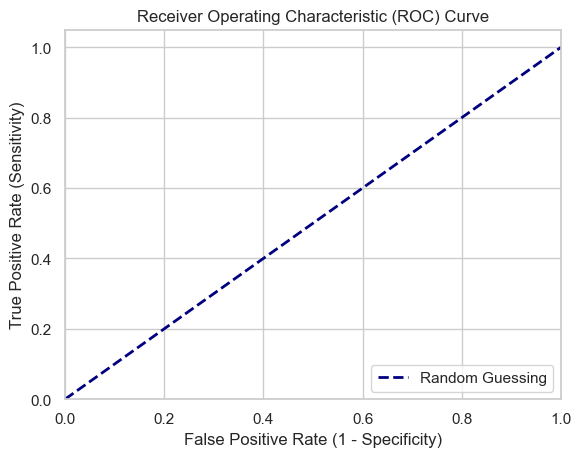

In [11]:
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()